# Compute-cost figures for §3.8

Reads the artifacts that training and evaluation already wrote, and produces the
two figures used in the thesis:

- **Σχήμα 7** — training wall time per experimental condition
- **Σχήμα 8** — evaluation wall time per experimental condition

Nothing is retrained or re-evaluated and no artifact is modified. Training time
comes from the `dt_seconds` column of each run's `metrics.csv`; evaluation time
comes from the stage table in `thesis_eval/final/summary__unified_eval_v4.md`.

Training ran on the Colab **G4** GPU (NVIDIA RTX PRO 6000 Blackwell) and
evaluation on **L4** (NVIDIA L4, Ada Lovelace), so the two figures share a y
axis for readability but are **not** comparable to each other.

## Paths

In [1]:
from pathlib import Path
import csv
import re

CANDIDATE_ARTIFACT_ROOTS = [
    Path("/content/drive/MyDrive/Master_Thesis_Artifacts"),
    Path("G:/My Drive/Master_Thesis_Artifacts"),
]
CANDIDATE_FIGURE_DIRS = [
    Path("/content/drive/Othercomputers/MyLaptop/Master_Thesis_Code_Final/Main_Experimentation_Results/Chapter_5"),
    Path("C:/Users/Babis/Dropbox/MSc_AI/Master_Thesis_Code_Final/Main_Experimentation_Results/Chapter_5"),
]

if not any(p.is_dir() for p in CANDIDATE_ARTIFACT_ROOTS):
    from google.colab import drive
    drive.mount("/content/drive")

ARTIFACTS_ROOT = next(p for p in CANDIDATE_ARTIFACT_ROOTS if p.is_dir())
FIGURE_DIR = next((p for p in CANDIDATE_FIGURE_DIRS if p.is_dir()), Path("."))
RUNS_ROOT = ARTIFACTS_ROOT / "runs"
assert RUNS_ROOT.is_dir(), RUNS_ROOT
print("artifacts:", ARTIFACTS_ROOT)
print("figures  :", FIGURE_DIR)

Mounted at /content/drive
artifacts: /content/drive/MyDrive/Master_Thesis_Artifacts
figures  : /content/drive/Othercomputers/MyLaptop/Master_Thesis_Code_Final/Main_Experimentation_Results/Chapter_5


## Run registry

One entry per cell of the 2 × 2 × 3 design. Edit here if a run is moved or
renamed — nothing below hard-codes a path.

In [2]:
BOARDS = [8, 12, 16]
CONDITIONS = ["Transformer · AR", "Mamba · AR", "Transformer · JEPA", "Mamba · JEPA"]

TRAIN_RUNS = {
    ("Transformer · AR", 8):    "Transformer-AR/transformer_ar_b8_bf16",
    ("Transformer · AR", 12):   "Transformer-AR/transformer_ar_b12",
    ("Transformer · AR", 16):   "Transformer-AR/transformer_ar_b16",
    ("Mamba · AR", 8):          "Mamba-AR/mamba_ar_8x8_bf16",
    ("Mamba · AR", 12):         "Mamba-AR/mamba_ar_b12",
    ("Mamba · AR", 16):         "Mamba-AR/mamba_ar_b16",
    ("Transformer · JEPA", 8):  "Transformer-JEPA/jepa_v5_infonce_b8_run_001_hd_allpos_bf16",
    ("Transformer · JEPA", 12): "Transformer-JEPA/transformer_jepa_v5_hd_infonce_allpos_b12",
    ("Transformer · JEPA", 16): "Transformer-JEPA/transformer_jepa_v5_hd_infonce_allpos_b16",
    ("Mamba · JEPA", 8):        "Mamba-JEPA/mamba_jepa_v5_hd_infonce_allpos_b8",
    ("Mamba · JEPA", 12):       "Mamba-JEPA/mamba_jepa_v5_hd_infonce_allpos_b12",
    ("Mamba · JEPA", 16):       "Mamba-JEPA/mamba_jepa_v5_hd_infonce_allpos_b16",
}

# Every cell is now evaluated in its own run folder: the two 8x8 AR bf16 runs
# received their unified_eval_v4 evaluation with the seed-42 pass of the
# multi-seed suite, so no substitution is needed any more.
EVAL_RUNS = dict(TRAIN_RUNS)

EVAL_SUMMARY = "thesis_eval/final/summary__unified_eval_v4.md"

## Readers

In [3]:
def training_hours(run_relative):
    """Sum the per-shard dt_seconds column written by the trainer."""
    path = RUNS_ROOT / run_relative / "metrics.csv"
    if not path.is_file():
        return None, f"missing {path}"
    with path.open(newline="", encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        return None, f"empty {path}"
    seconds = sum(float(r["dt_seconds"]) for r in rows if r.get("dt_seconds"))
    return seconds / 3600, f"{len(rows)} shards"


STAGE_ROW = re.compile(r"^\| ([a-z_0-9]+) \| ([\d.]+) s \|", re.M)


def evaluation_stages(run_relative):
    """Per-stage wall time from the summary the evaluator writes."""
    path = RUNS_ROOT / run_relative / EVAL_SUMMARY
    if not path.is_file():
        return None, f"missing {path}"
    stages = {name: float(value)
              for name, value in STAGE_ROW.findall(path.read_text(encoding="utf-8"))}
    if not stages:
        return None, f"no timing table in {path}"
    return stages, f"{len(stages)} stages"

## Collect

Any cell whose artifacts are missing is reported rather than silently dropped,
and is drawn as a zero-height bar.

In [4]:
records = []
for condition in CONDITIONS:
    for board in BOARDS:
        train_h, train_note = training_hours(TRAIN_RUNS[(condition, board)])
        stages, eval_note = evaluation_stages(EVAL_RUNS[(condition, board)])
        records.append({
            "condition": condition,
            "board": board,
            "training_hours": train_h,
            "evaluation_hours": sum(stages.values()) / 3600 if stages else None,
            "stages": stages or {},
            "notes": f"train: {train_note} · eval: {eval_note}",
        })

print(f"{'condition':<20}{'board':>8}{'train h':>10}{'eval h':>9}")
for r in records:
    t = f"{r['training_hours']:.2f}" if r["training_hours"] is not None else "—"
    e = f"{r['evaluation_hours']:.2f}" if r["evaluation_hours"] is not None else "—"
    print(f"{r['condition']:<20}{str(r['board']) + '×' + str(r['board']):>8}{t:>10}{e:>9}")

incomplete = [r for r in records
              if r["training_hours"] is None or r["evaluation_hours"] is None]
if incomplete:
    print("\nINCOMPLETE — these cells need a run or an evaluation:")
    for r in incomplete:
        print(" ", r["condition"], r["board"], "|", r["notes"])

total_train = sum(r["training_hours"] or 0 for r in records)
total_eval = sum(r["evaluation_hours"] or 0 for r in records)
print(f"\ntotal training  : {total_train:.1f} h")
print(f"total evaluation: {total_eval:.1f} h")

condition              board   train h   eval h
Transformer · AR         8×8      0.68     0.42
Transformer · AR       12×12      1.85     1.72
Transformer · AR       16×16      4.39     5.18
Mamba · AR               8×8      2.11     0.46
Mamba · AR             12×12      3.62     1.77
Mamba · AR             16×16      4.70     5.22
Transformer · JEPA       8×8      1.54     0.99
Transformer · JEPA     12×12      4.58     4.04
Transformer · JEPA     16×16      9.53    12.13
Mamba · JEPA             8×8      3.27     1.58
Mamba · JEPA           12×12      6.62     4.36
Mamba · JEPA           16×16     11.40    12.06

total training  : 54.3 h
total evaluation: 49.9 h


## Evaluation cost by stage

Where the evaluation budget actually goes. For AR it is the 50,000-game legality
pass; for JEPA it is the frozen-head training that has to happen first.

In [5]:
stage_names = sorted({s for r in records for s in r["stages"]})
width = max(len(s) for s in stage_names) if stage_names else 0
for r in records:
    if not r["stages"]:
        continue
    print(f"{r['condition']} {r['board']}×{r['board']}")
    for name, seconds in sorted(r["stages"].items(), key=lambda kv: -kv[1]):
        print(f"   {name:<{width}}  {seconds / 60:7.1f} min")

Transformer · AR 8×8
   native_ar                    19.5 min
   board_feature_extraction      2.5 min
   board_probe_mlp               1.1 min
   causal_intervention           1.1 min
   board_probe_linear            1.0 min
Transformer · AR 12×12
   native_ar                    90.8 min
   board_feature_extraction      9.5 min
   board_probe_mlp               1.5 min
   board_probe_linear            1.4 min
Transformer · AR 16×16
   native_ar                   279.3 min
   board_feature_extraction     27.8 min
   board_probe_mlp               1.9 min
   board_probe_linear            1.7 min
Mamba · AR 8×8
   native_ar                    19.3 min
   board_feature_extraction      3.0 min
   board_probe_mlp               1.9 min
   causal_intervention           1.8 min
   board_probe_linear            1.6 min
Mamba · AR 12×12
   native_ar                    90.7 min
   board_feature_extraction     10.2 min
   board_probe_mlp               2.7 min
   board_probe_linear            2.4 min

## Figures

Colours are categorical slots 1–4 of the validated thesis palette; every bar
carries a visible value label, which is what licenses the two low-contrast
slots. The two figures share one y axis so the shapes can be compared within
each figure at a glance.

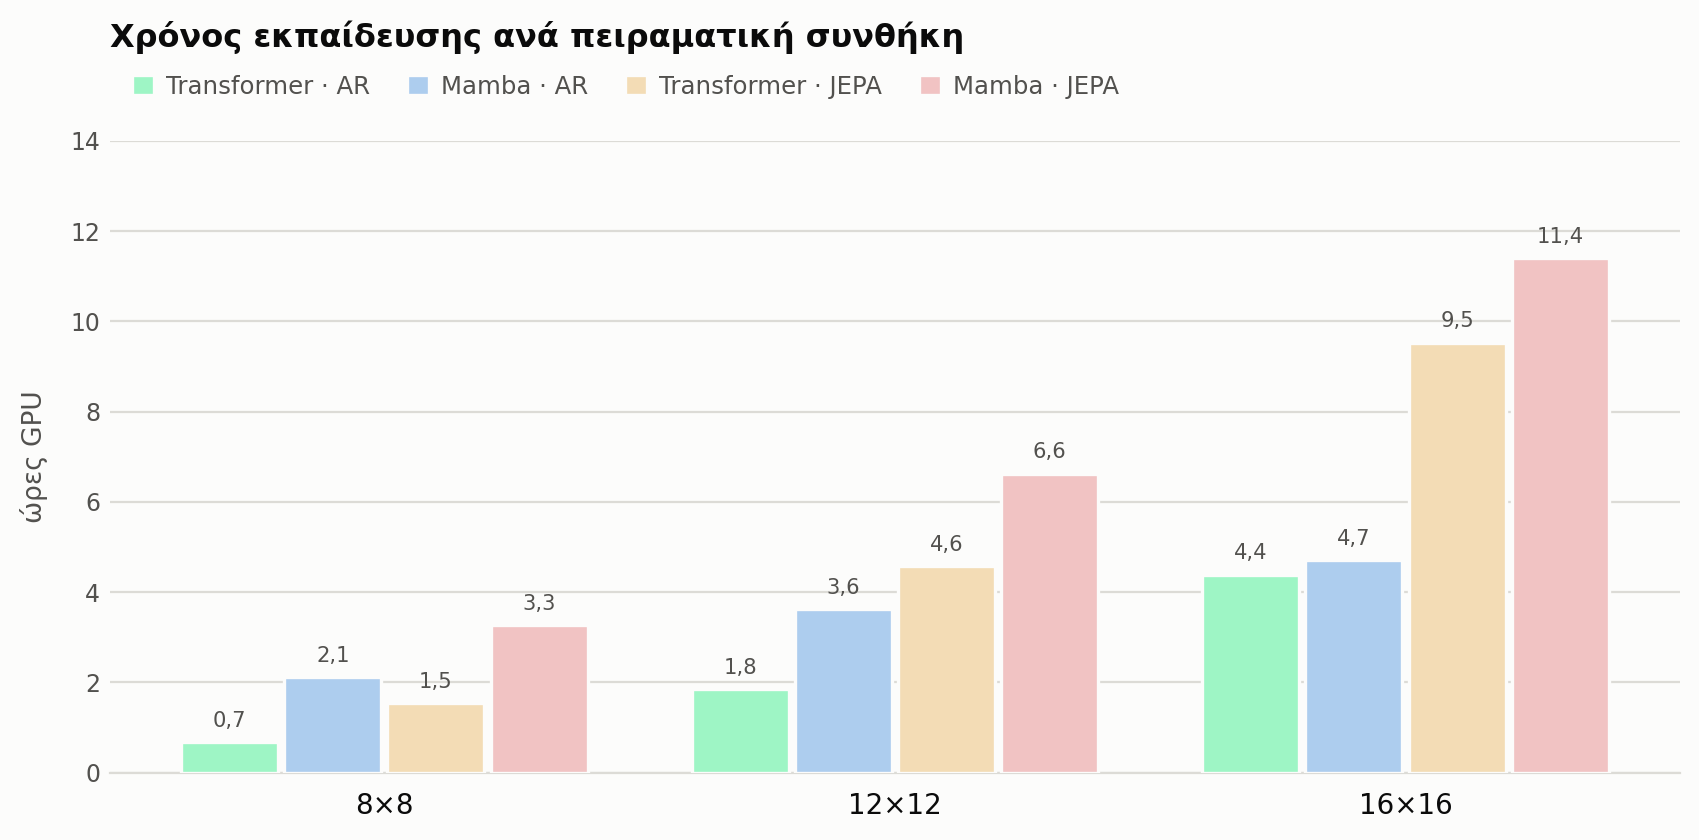

wrote /content/drive/Othercomputers/MyLaptop/Master_Thesis_Code_Final/Main_Experimentation_Results/Chapter_5/fig_training_time.png


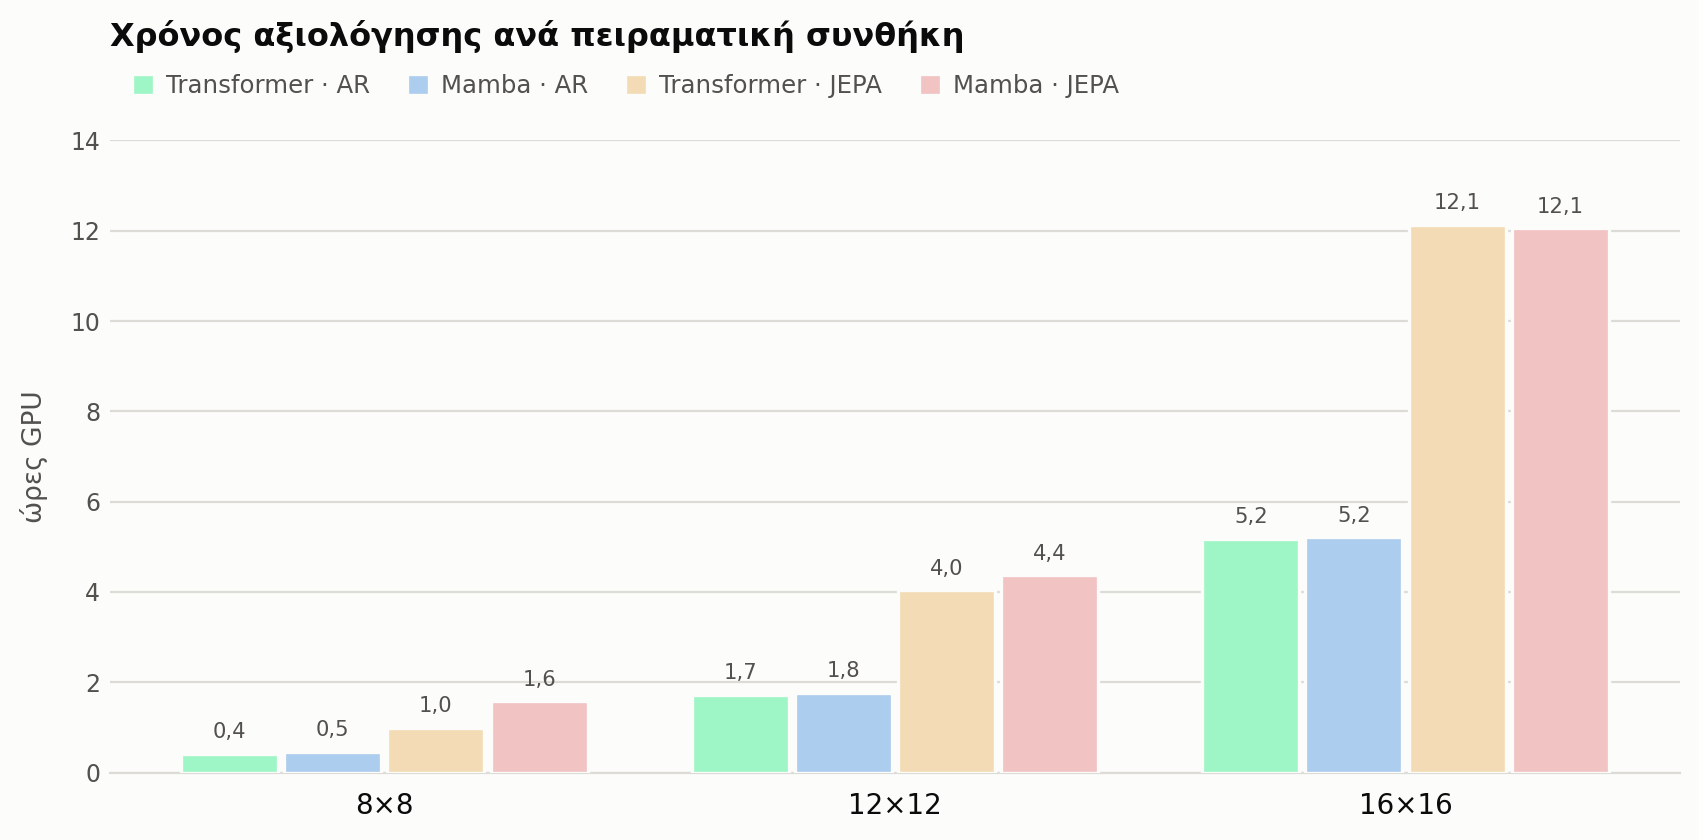

wrote /content/drive/Othercomputers/MyLaptop/Master_Thesis_Code_Final/Main_Experimentation_Results/Chapter_5/fig_eval_time.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdbd6"
SERIES = ["#8AB99F", "#ADCDEE", "#F3DCB5", "#F1C3C3"]


def grouped_bars(values, title, filename, ymax):
    fig, ax = plt.subplots(figsize=(8.6, 4.3), dpi=200)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)
    width, gap, n = 0.19, 0.012, len(CONDITIONS)
    for i, condition in enumerate(CONDITIONS):
        xs = [b + (i - (n - 1) / 2) * (width + gap) for b in range(len(BOARDS))]
        ys = [values.get((condition, b)) or 0.0 for b in BOARDS]
        ax.bar(xs, ys, width, label=condition, color=SERIES[i],
               edgecolor=SURFACE, linewidth=1.2, zorder=3)
        for x, y in zip(xs, ys):
            if y:
                ax.text(x, y + ymax * 0.018, f"{y:.1f}".replace(".", ","),
                        ha="center", va="bottom", fontsize=7.6, color=INK2, zorder=4)
    ax.set_xticks(range(len(BOARDS)))
    ax.set_xticklabels([f"{b}×{b}" for b in BOARDS], fontsize=10, color=INK)
    ax.set_ylabel("ώρες GPU", fontsize=9.5, color=INK2, labelpad=8)
    ax.set_ylim(0, ymax)
    ax.yaxis.set_major_locator(MultipleLocator(2))
    ax.tick_params(axis="y", labelsize=8.5, colors=INK2, length=0)
    ax.tick_params(axis="x", length=0, pad=7)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.set_title(title, fontsize=11.5, color=INK, pad=34,
                 loc="left", fontweight="semibold")
    ax.legend(loc="upper left", bbox_to_anchor=(0, 1.14), ncol=4, frameon=False,
              fontsize=8.8, labelcolor=INK2, handlelength=0.9, handleheight=0.9,
              columnspacing=1.5, handletextpad=0.5)
    fig.tight_layout()
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / filename, facecolor=SURFACE, bbox_inches="tight")
    plt.show()
    print("wrote", FIGURE_DIR / filename)


train_map = {(r["condition"], r["board"]): r["training_hours"] for r in records}
eval_map = {(r["condition"], r["board"]): r["evaluation_hours"] for r in records}
peak = max(v for v in list(train_map.values()) + list(eval_map.values()) if v)
YMAX = 2 * ((peak * 1.12) // 2 + 1)

grouped_bars(train_map, "Χρόνος εκπαίδευσης ανά πειραματική συνθήκη",
             "fig_training_time.png", YMAX)
grouped_bars(eval_map, "Χρόνος αξιολόγησης ανά πειραματική συνθήκη",
             "fig_eval_time.png", YMAX)

## Numbers as CSV

So the figures and any number quoted in the text come from one source.

In [7]:
out_csv = FIGURE_DIR / "compute_cost.csv"
with out_csv.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow(["condition", "board", "training_hours", "evaluation_hours",
                     "train_run", "eval_run"])
    for r in records:
        writer.writerow([
            r["condition"], f"{r['board']}x{r['board']}",
            f"{r['training_hours']:.4f}" if r["training_hours"] is not None else "",
            f"{r['evaluation_hours']:.4f}" if r["evaluation_hours"] is not None else "",
            TRAIN_RUNS[(r["condition"], r["board"])],
            EVAL_RUNS[(r["condition"], r["board"])],
        ])
print("wrote", out_csv)

wrote /content/drive/Othercomputers/MyLaptop/Master_Thesis_Code_Final/Main_Experimentation_Results/Chapter_5/compute_cost.csv
